# Import Packages

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
import os
import shutil
from sklearn.model_selection import train_test_split
import glob
import time
import copy
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from PIL import Image

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.8.0+cu129
CUDA available: True
Using device: cuda:0


# Configuration & Data Splitting

In [2]:
# Path to  augmented dataset containing 'Cancer' and 'Non-Cancer' folders
source_data_dir = '../data/Breast Cancer Dataset Mendeley/Augmented Dataset/'
# Where to create the new 'train' and 'validation' folders
output_data_dir = '../data/Breast Cancer Dataset Mendeley/Augmented_Split/'

# --- Splitting Parameters ---
validation_split_size = 0.2 # Use 20% of the data for validation
random_seed = 42 # For reproducibility

# --- Check if split already exists ---
if not os.path.exists(os.path.join(output_data_dir, 'train')) or \
   not os.path.exists(os.path.join(output_data_dir, 'validation')):
    print(f"Creating train/validation split in '{output_data_dir}'...")

    # Create Output Directories
    os.makedirs(os.path.join(output_data_dir, 'train', 'Cancer'), exist_ok=True)
    os.makedirs(os.path.join(output_data_dir, 'train', 'Non-Cancer'), exist_ok=True)
    os.makedirs(os.path.join(output_data_dir, 'validation', 'Cancer'), exist_ok=True)
    os.makedirs(os.path.join(output_data_dir, 'validation', 'Non-Cancer'), exist_ok=True)

    # Split and Copy Files for Each Class
    for class_name in ['Cancer', 'Non-Cancer']:
        print(f"Processing class: {class_name}")
        class_source_dir = os.path.join(source_data_dir, class_name)

        # Find all image files
        image_files = glob.glob(os.path.join(class_source_dir, '*.png')) + \
                      glob.glob(os.path.join(class_source_dir, '*.jpg')) + \
                      glob.glob(os.path.join(class_source_dir, '*.jpeg'))

        if not image_files:
            print(f"Warning: No image files found in {class_source_dir}")
            continue

        # Split the file list
        train_files, val_files = train_test_split(
            image_files,
            test_size=validation_split_size,
            random_state=random_seed
        )

        # Copy files to the 'train' directory
        train_dest_dir = os.path.join(output_data_dir, 'train', class_name)
        for file_path in train_files:
            shutil.copy(file_path, os.path.join(train_dest_dir, os.path.basename(file_path)))

        # Copy files to the 'validation' directory
        val_dest_dir = os.path.join(output_data_dir, 'validation', class_name)
        for file_path in val_files:
            shutil.copy(file_path, os.path.join(val_dest_dir, os.path.basename(file_path)))

        print(f"  - Copied {len(train_files)} images to train/{class_name}")
        print(f"  - Copied {len(val_files)} images to validation/{class_name}")

    print("\nData splitting complete!")
else:
    print(f"Train/validation split already exists in '{output_data_dir}'. Skipping split.")

Creating train/validation split in '../data/Breast Cancer Dataset Mendeley/Augmented_Split/'...
Processing class: Cancer
  - Copied 1300 images to train/Cancer
  - Copied 325 images to validation/Cancer
Processing class: Non-Cancer
  - Copied 6448 images to train/Non-Cancer
  - Copied 1612 images to validation/Non-Cancer

Data splitting complete!


# Data Loading and Preprocessing

In [8]:
# Define transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet stats
    ]),
    'validation': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = output_data_dir # Use the split data directory

# Create datasets using ImageFolder
try:
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                      for x in ['train', 'validation']}
except FileNotFoundError:
    print(f"Error: Could not find 'train' and/or 'validation' folders inside '{data_dir}'.")
    exit()

# Create DataLoaders
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32, # Batch size
                                             shuffle=True, num_workers=6) # Use num_workers > 0
               for x in ['train', 'validation']}

# Get dataset sizes and class names
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'validation']}
class_names = image_datasets['train'].classes

print(f"Classes found: {class_names}")
print(f"Training images: {dataset_sizes['train']}")
print(f"Validation images: {dataset_sizes['validation']}")

Classes found: ['Cancer', 'Non-Cancer']
Training images: 7748
Validation images: 1937


# Load Pre-trained ResNet50 & Modify Final Layer

In [4]:
# Load pre-trained ResNet50
model_ft = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Modify the final fully connected layer for binary classification
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names)) # Output size = number of classes

# Move the model to the GPU if available
model_ft = model_ft.to(device)

print("ResNet50 loaded and final layer modified.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Cliffton/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 42.3MB/s]


ResNet50 loaded and final layer modified.


# Define Loss Function & Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized (fine-tuning the whole model)
optimizer_ft = optim.AdamW(model_ft.parameters(), lr=0.001) # Fine-tune all parameters

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# Training Loop Function

In [13]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("\nStarting training...")
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data. Add tqdm here if desired.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Store history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                # Save the best model weights
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print(f" ** New best validation accuracy: {best_acc:.4f} **")


        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Start Training

In [14]:
num_epochs_to_train = 15 # Adjust as needed

model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                           num_epochs=num_epochs_to_train)


Starting training...
Epoch 0/14
----------
train Loss: 0.2214 Acc: 0.9156
validation Loss: 0.1022 Acc: 0.9685
 ** New best validation accuracy: 0.9685 **

Epoch 1/14
----------
train Loss: 0.2042 Acc: 0.9246
validation Loss: 6.0938 Acc: 0.2793

Epoch 2/14
----------
train Loss: 0.1999 Acc: 0.9242
validation Loss: 0.0892 Acc: 0.9711
 ** New best validation accuracy: 0.9711 **

Epoch 3/14
----------
train Loss: 0.1693 Acc: 0.9351
validation Loss: 0.5532 Acc: 0.9654

Epoch 4/14
----------
train Loss: 0.1769 Acc: 0.9331
validation Loss: 0.0910 Acc: 0.9623

Epoch 5/14
----------
train Loss: 0.1922 Acc: 0.9267
validation Loss: 0.0785 Acc: 0.9830
 ** New best validation accuracy: 0.9830 **

Epoch 6/14
----------
train Loss: 0.1636 Acc: 0.9364
validation Loss: 0.0432 Acc: 0.9881
 ** New best validation accuracy: 0.9881 **

Epoch 7/14
----------
train Loss: 0.1468 Acc: 0.9433
validation Loss: 0.0353 Acc: 0.9923
 ** New best validation accuracy: 0.9923 **

Epoch 8/14
----------
train Loss: 0.13

# Plot Training History


Plotting training history...


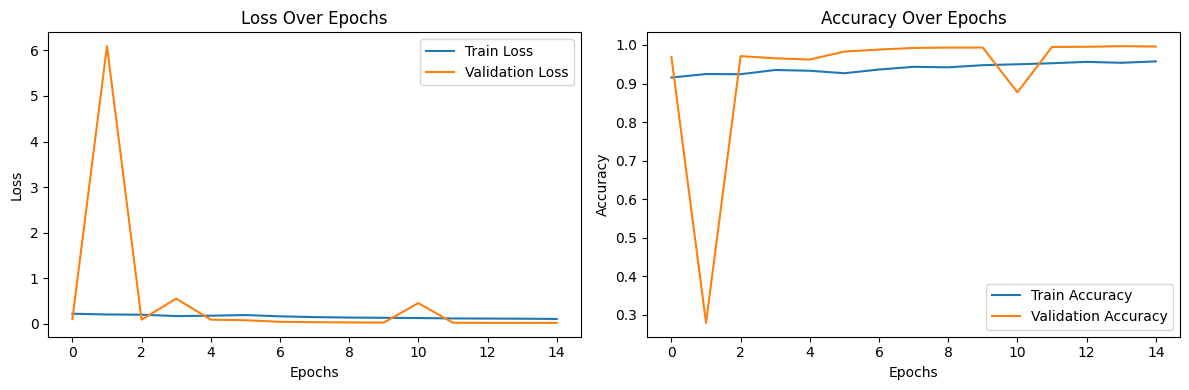

In [15]:
def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nPlotting training history...")
plot_history(history)

# Save Best Model

In [16]:
# Define path within your project structure
save_path = './resnet50_model/resnet50_best_weights.pth'
os.makedirs(os.path.dirname(save_path), exist_ok=True) # Create directory if it doesn't exist

# Save the model's state dictionary
torch.save(model_ft.state_dict(), save_path)
print(f"Best model weights saved to {save_path}")

print("\n--- Process Complete ---")

Best model weights saved to ./resnet50_model/resnet50_best_weights.pth

--- Process Complete ---


# Prediction on Entire Augmented Dataset

In [20]:
model_to_predict = models.resnet50(weights=None) # Start with an untrained model shell
num_ftrs = model_to_predict.fc.in_features
model_to_predict.fc = nn.Linear(num_ftrs, len(class_names))

# Load the saved state dictionary
save_path = './resnet50_model/resnet50_best_weights.pth'
model_to_predict.load_state_dict(torch.load(save_path))
model_to_predict = model_to_predict.to(device)

# Set the model to evaluation mode
model_to_predict.eval()
print("Model loaded and set to evaluation mode.")


#  Define a prediction function
def predict_images(image_paths, model, transform, class_names):
    predictions = []
    with torch.no_grad(): # Disable gradient calculation for speed
        for img_path in image_paths:
            try:
                # Open image and apply validation transform
                image = Image.open(img_path).convert('RGB') # Ensure 3 channels
                image_tensor = transform(image).unsqueeze(0) # Add batch dimension
                image_tensor = image_tensor.to(device)
                
                # Get model output
                outputs = model(image_tensor)
                _, pred_index = torch.max(outputs, 1)
                
                # Convert index to class name
                pred_class = class_names[pred_index.item()]
                predictions.append((img_path, pred_class))
                
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                predictions.append((img_path, "Error"))
    return predictions

# Get all images from the original augmented dataset
source_data_dir = '../data/Breast Cancer Dataset Mendeley/Augmented Dataset/'

all_cancer_images = glob.glob(os.path.join(source_data_dir, 'Cancer', '*.*'))
all_non_cancer_images = glob.glob(os.path.join(source_data_dir, 'Non-Cancer', '*.*'))

all_images_list = all_cancer_images + all_non_cancer_images
print(f"Found {len(all_images_list)} total images to predict on.")

# Run predictions
print("Starting predictions on all images...")
all_predictions = predict_images(
    all_images_list, 
    model_to_predict, 
    data_transforms['validation'], # Use the validation transform
    class_names
)

print("Predictions complete.")

#  Display some results
print("\n--- Sample Predictions ---")
for i, (img_path, prediction) in enumerate(all_predictions[:10]): # Show first 10
    true_label = "Cancer" if "Cancer" in img_path else "Non-Cancer"
    print(f"Image: {os.path.basename(img_path)} | Predicted: {prediction} | True: {true_label}")

# Also check for any mistakes
correct_count = 0
for img_path, prediction in all_predictions:
    
    # Get the name of the immediate parent folder (e.g., 'Cancer' or 'Non-Cancer')
    true_label = os.path.basename(os.path.dirname(img_path))

    if i < 10: 
        print(f"Image: {os.path.basename(img_path)} | Predicted: {prediction} | True: {true_label}")
    
    if prediction == true_label:
        correct_count += 1
    i += 1

print(f"\nOverall Accuracy on all {len(all_images_list)} images: {100 * correct_count / len(all_images_list):.2f}%")

Model loaded and set to evaluation mode.
Found 9685 total images to predict on.
Starting predictions on all images...
Predictions complete.

--- Sample Predictions ---
Image: IMG (1).jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_AdditiveGaussianNoise.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_Crop.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_Dropout.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_ElasticTransformation.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_Fliplr.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_GaussianBlur.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_LinearContrast.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_Multiply.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1)_PerspectiveTransform.jpg | Predicted: Cancer | True: Cancer
Image: IMG (1).jpg | Predicted: Cancer | True: Cancer

Overall Accuracy on all 9685 images: 99.60%


# Prediction on Entire Original Dataset

In [21]:
# Define the path to your Original Dataset 
original_data_dir = '../data/Breast Cancer Dataset Mendeley/Original Dataset/'

# Get all images from the original dataset 
print(f"Finding images in {original_data_dir}...")
original_cancer_images = glob.glob(os.path.join(original_data_dir, 'Cancer', '*.*'))
original_non_cancer_images = glob.glob(os.path.join(original_data_dir, 'Non-Cancer', '*.*'))

original_images_list = original_cancer_images + original_non_cancer_images
print(f"Found {len(original_images_list)} original images to predict on.")

# Run predictions 
print("Starting predictions on original dataset...")
original_predictions = predict_images(
    original_images_list,
    model_to_predict,
    data_transforms['validation'],
    class_names
)
print("Predictions complete.")

# Display results and calculate accuracy 
print("\n--- Original Dataset Predictions ---")
correct_count_orig = 0
for i, (img_path, prediction) in enumerate(original_predictions):

    # Get the true label from the parent folder name
    true_label = os.path.basename(os.path.dirname(img_path))

    if i < 10: # Show first 10
        print(f"Image: {os.path.basename(img_path)} | Predicted: {prediction} | True: {true_label}")

    if prediction == true_label:
        correct_count_orig += 1

# Show Final Accuracy 
print(f"\nOverall Accuracy on all {len(original_images_list)} original images: {100 * correct_count_orig / len(original_images_list):.2f}%")

Finding images in ../data/Breast Cancer Dataset Mendeley/Original Dataset/...
Found 745 original images to predict on.
Starting predictions on original dataset...
Predictions complete.

--- Original Dataset Predictions ---
Image: IMG (1).jpg | Predicted: Cancer | True: Cancer
Image: IMG (10).jpg | Predicted: Cancer | True: Cancer
Image: IMG (100).jpg | Predicted: Cancer | True: Cancer
Image: IMG (101).jpg | Predicted: Cancer | True: Cancer
Image: IMG (102).jpg | Predicted: Cancer | True: Cancer
Image: IMG (103).jpg | Predicted: Cancer | True: Cancer
Image: IMG (104).jpg | Predicted: Cancer | True: Cancer
Image: IMG (105).jpg | Predicted: Cancer | True: Cancer
Image: IMG (106).jpg | Predicted: Cancer | True: Cancer
Image: IMG (107).jpg | Predicted: Cancer | True: Cancer

Overall Accuracy on all 745 original images: 99.73%
